In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("social_media_sleep_stress_productivity_11000.csv")

In [5]:
df.head()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
0,1,44,2.39,1.93,8.46,61,3.73,33.86,Low,YouTube
1,2,30,7.22,5.24,7.34,28,6.80,85.32,Low,YouTube
2,3,23,2.56,4.64,4.69,8,4.47,60.07,High,YouTube
3,4,36,8.75,4.89,5.05,53,9.53,36.46,Medium,LinkedIn
4,5,34,10.96,2.77,7.12,83,7.01,32.93,Medium,Instagram


In [6]:
pd.set_option("display.max_columns", None)

In [7]:
df.tail()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
10995,10996,27,8.25,7.69,6.40,82,2.08,23.52,Low,LinkedIn
10996,10997,35,8.55,6.88,6.43,62,6.67,48.11,High,YouTube
10997,10998,38,1.25,6.66,7.21,104,7.72,14.62,Low,Instagram
10998,10999,45,1.59,4.02,3.50,106,8.86,39.40,Low,Snapchat
10999,11000,45,6.86,2.09,7.48,33,6.24,38.82,Medium,Twitter


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  11000 non-null  int64  
 1   age                      11000 non-null  int64  
 2   daily_screen_time_hours  11000 non-null  float64
 3   social_media_hours       11000 non-null  float64
 4   sleep_hours              11000 non-null  float64
 5   exercise_minutes         11000 non-null  int64  
 6   study_work_hours         11000 non-null  float64
 7   productivity_score       11000 non-null  float64
 8   stress_level             11000 non-null  object 
 9   platform                 11000 non-null  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 859.5+ KB


### Sanity Check for Synthetic Data

In [10]:
error_mask = df['social_media_hours'] > df['daily_screen_time_hours']

In [11]:
error_mask

0        False
1        False
2         True
3        False
4        False
         ...  
10995    False
10996    False
10997     True
10998     True
10999    False
Length: 11000, dtype: bool

In [13]:
# Number of Rows that doesn't make sense on our synthetic data. (Social Media Hours > Daily Screen Time Hours)

print(f"Distorted Data Count: {error_mask.sum()}")

Distorted Data Count: 3217


In [14]:
df["total_activity_hours"] = df["sleep_hours"] + df["daily_screen_time_hours"] + (df["exercise_minutes"]/60) + df["study_work_hours"]

In [15]:
overtime_mask = df["total_activity_hours"] > 24

In [22]:
# Number of Rows that doesn't make sense on our synthetic data. (Total Hours > 24)

overtime_mask.sum()

np.int64(1613)

In [21]:
df = df.drop(df[overtime_mask].index, axis = 0)

In [23]:
df["total_activity_hours"] = df["sleep_hours"] + df["daily_screen_time_hours"] + (df["exercise_minutes"]/60) + df["study_work_hours"]
overtime_mask = df["total_activity_hours"] > 24
overtime_mask.sum()

np.int64(0)

In [24]:
error_mask = df['social_media_hours'] > df['daily_screen_time_hours']

In [25]:
print(f"Distorted Data Count: {error_mask.sum()}")

Distorted Data Count: 3181


In [26]:
df = df.drop(df[error_mask].index, axis = 0)

In [27]:
error_mask = df['social_media_hours'] > df['daily_screen_time_hours']

In [28]:
print(f"Distorted Data Count: {error_mask.sum()}")

Distorted Data Count: 0


## Feature Engineering

In [34]:
stress_map = {"Low": 0, "Medium":1, "High":2}

In [35]:
df["stress_level_numeric"] = df["stress_level"].map(stress_map)

In [39]:
df_final = pd.get_dummies(df, columns = ["platform"], prefix ="platform")

In [40]:
df_final.head()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,total_activity_hours,stress_level_numeric,platform_Instagram,platform_LinkedIn,platform_Snapchat,platform_Twitter,platform_YouTube
0,1,44,2.39,1.93,8.46,61,3.73,33.86,Low,15.596667,0,False,False,False,False,True
1,2,30,7.22,5.24,7.34,28,6.80,85.32,Low,21.826667,0,False,False,False,False,True
5,6,38,5.78,5.30,5.87,113,8.78,32.74,Low,22.313333,0,True,False,False,False,False
7,8,26,11.20,7.99,3.85,18,5.05,11.03,High,20.400000,2,False,False,True,False,False
9,10,39,6.36,4.68,4.97,73,9.06,31.91,High,21.606667,2,False,False,False,False,True


## EDA

### Univariate Analysis

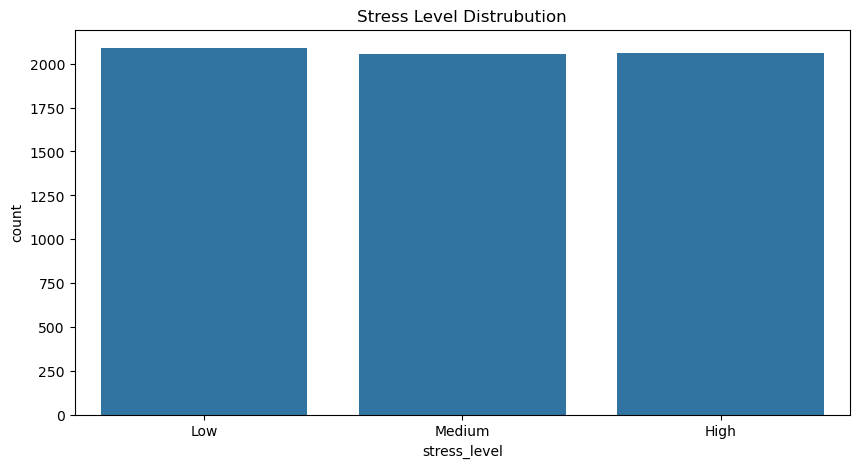

In [41]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x="stress_level", order = ["Low", "Medium", "High"])
plt.title("Stress Level Distrubution")
plt.show()

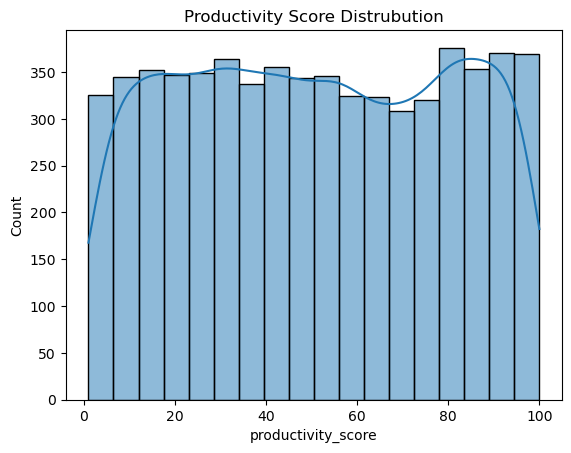

In [33]:
sns.histplot(df["productivity_score"], kde = True)
plt.title("Productivity Score Distrubution")
plt.show()

### Bivariate Analysis and Correlation